In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [31]:
!pip install ultralytics

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

class YogaPoseDetector:
    def __init__(self, model_name='yolov8n-pose.pt', conf=0.5):
        """
        Initialize pose detection model
        model_name: Use 'yolov8n-pose.pt', 'yolov8s-pose.pt', 'yolov8m-pose.pt', etc.
        """
        self.model = YOLO(model_name)
        self.conf = conf
        
        # COCO keypoint names (17 keypoints)
        self.keypoint_names = [
            'Nose', 'L Eye', 'R Eye', 'L Ear', 'R Ear',
            'L Shoulder', 'R Shoulder', 'L Elbow', 'R Elbow',
            'L Wrist', 'R Wrist', 'L Hip', 'R Hip',
            'L Knee', 'R Knee', 'L Ankle', 'R Ankle'
        ]
        
        # Skeleton connections for drawing
        self.skeleton = [
            [16, 14], [14, 12], [17, 15], [15, 13], [12, 13],  # legs
            [6, 12], [7, 13],  # torso
            [6, 8], [8, 10], [7, 9], [9, 11],  # arms
            [6, 7],  # shoulders
            [1, 2], [1, 3], [2, 4], [3, 5],  # head
            [1, 6], [1, 7]  # neck
        ]
    
    def detect_pose(self, image_path):
        """Detect pose keypoints in an image"""
        image = cv2.imread(image_path)
        results = self.model(image, conf=self.conf)
        
        return results[0]
    
    def plot_pose(self, image_path, show_keypoint_names=False):
        """Visualize pose detection with skeleton overlay"""
        result = self.detect_pose(image_path)
        
        # Get original image
        image = result.orig_img.copy()
        
        # Check if any pose detected
        if result.keypoints is None or len(result.keypoints) == 0:
            print(f"No pose detected in {image_path}")
            return
        
        # Draw for each detected person
        for person_idx, keypoints in enumerate(result.keypoints):
            kpts = keypoints.xy[0].cpu().numpy()  # Get x,y coordinates
            conf = keypoints.conf[0].cpu().numpy()  # Get confidence scores
            
            # Draw skeleton lines
            for connection in self.skeleton:
                pt1_idx, pt2_idx = connection[0] - 1, connection[1] - 1  # Convert to 0-indexed
                
                if conf[pt1_idx] > 0.5 and conf[pt2_idx] > 0.5:
                    pt1 = tuple(kpts[pt1_idx].astype(int))
                    pt2 = tuple(kpts[pt2_idx].astype(int))
                    cv2.line(image, pt1, pt2, (0, 255, 0), 2)
            
            # Draw keypoints
            for i, (x, y) in enumerate(kpts):
                if conf[i] > 0.5:  # Only draw confident keypoints
                    cv2.circle(image, (int(x), int(y)), 5, (0, 0, 255), -1)
                    
                    # Optionally add keypoint names
                    if show_keypoint_names:
                        cv2.putText(image, self.keypoint_names[i], 
                                  (int(x) + 5, int(y) - 5),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)
        
        # Convert BGR to RGB for matplotlib
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Display
        plt.figure(figsize=(10, 10))
        plt.imshow(image_rgb)
        plt.title(f"Pose Detection: {image_path}")
        plt.axis('off')
        plt.show()
    
    def get_keypoints(self, image_path):
        """Extract keypoint coordinates and confidence scores"""
        result = self.detect_pose(image_path)
        
        if result.keypoints is None or len(result.keypoints) == 0:
            return None
        
        keypoints_data = []
        for person_idx, keypoints in enumerate(result.keypoints):
            kpts = keypoints.xy[0].cpu().numpy()
            conf = keypoints.conf[0].cpu().numpy()
            
            person_data = {
                'person_id': person_idx,
                'keypoints': {}
            }
            
            for i, name in enumerate(self.keypoint_names):
                person_data['keypoints'][name] = {
                    'x': float(kpts[i][0]),
                    'y': float(kpts[i][1]),
                    'confidence': float(conf[i])
                }
            
            keypoints_data.append(person_data)
        
        return keypoints_data


0: 480x640 1 person, 54.9ms
Speed: 2.1ms preprocess, 54.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


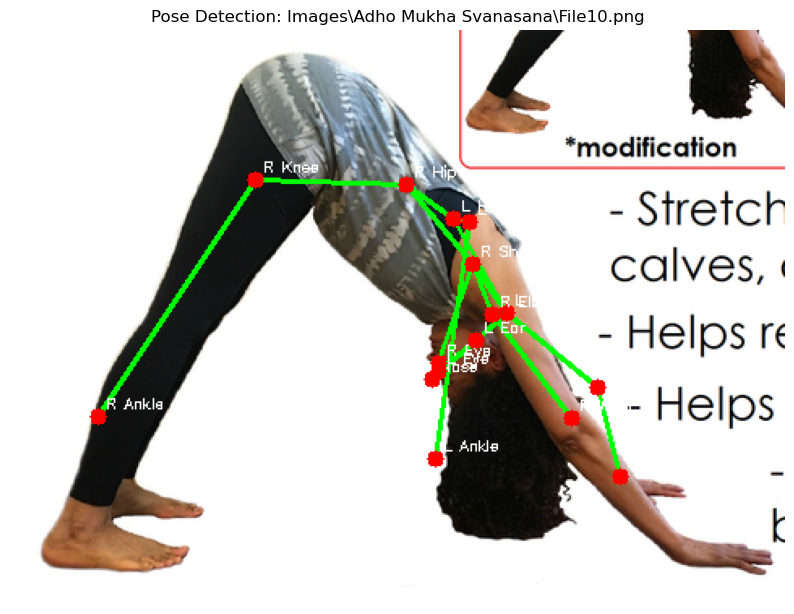


Class: Adho Mukha Svanasana

0: 352x640 1 person, 43.1ms
Speed: 1.9ms preprocess, 43.1ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)


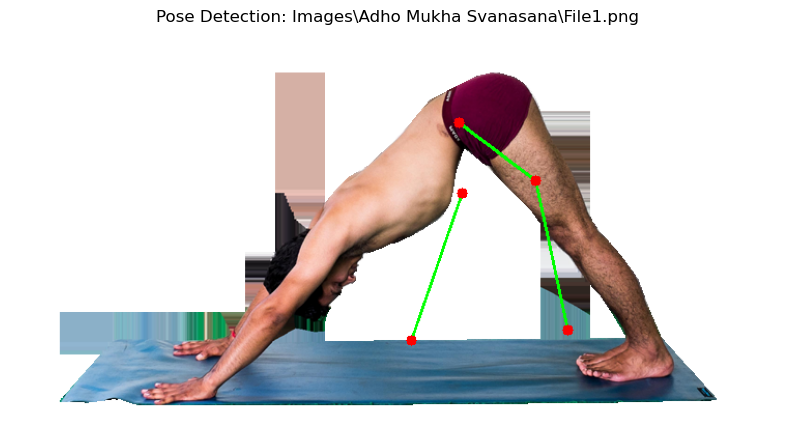

✓ File1.png

0: 480x640 1 person, 76.5ms
Speed: 1.6ms preprocess, 76.5ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


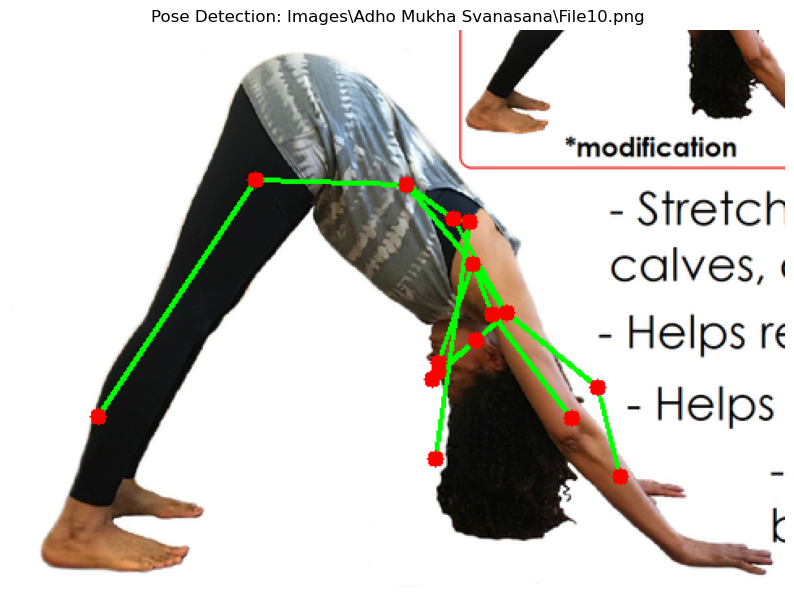

✓ File10.png

0: 544x640 1 person, 53.9ms
Speed: 3.1ms preprocess, 53.9ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)


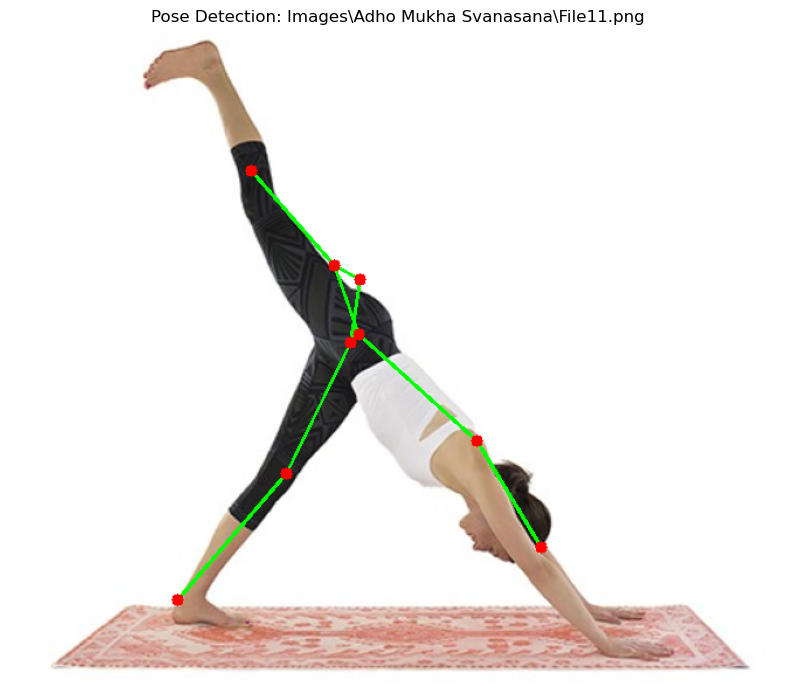

✓ File11.png

0: 480x640 1 person, 60.0ms
Speed: 1.7ms preprocess, 60.0ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


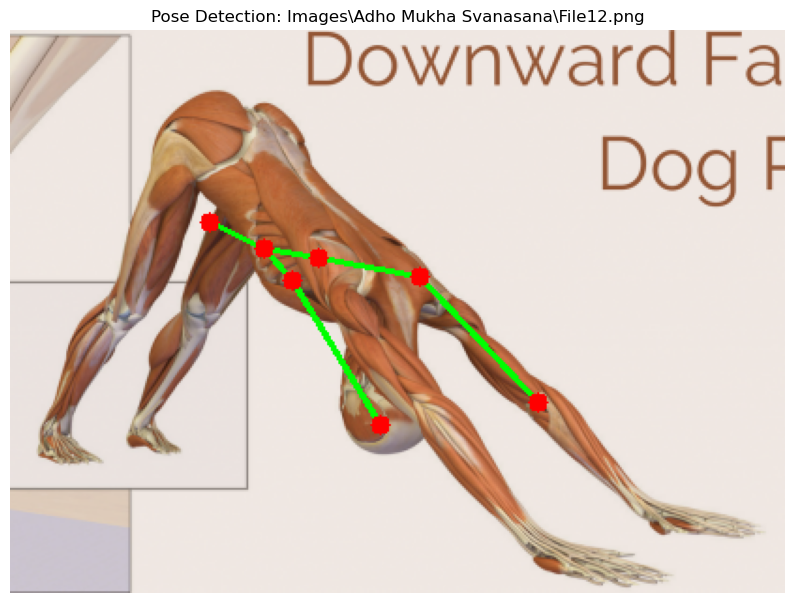

✓ File12.png

0: 384x640 1 person, 87.2ms
Speed: 2.0ms preprocess, 87.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


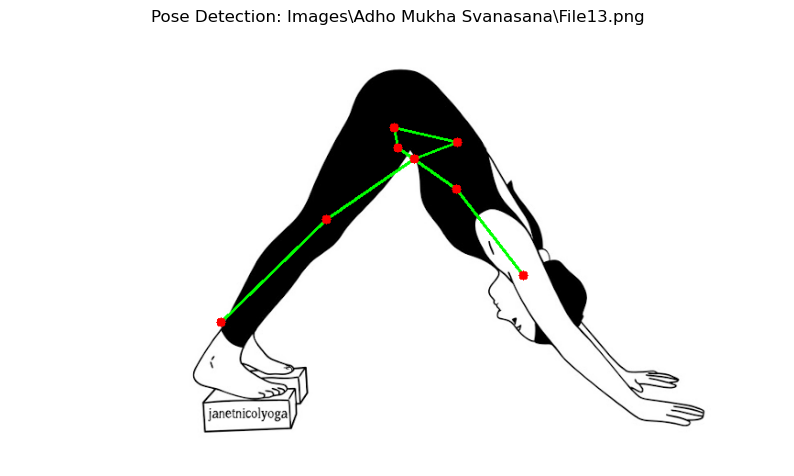

✓ File13.png

Summary: 5 successful, 0 failed (out of 5 examples)


In [33]:
import os
from pathlib import Path

# Initialize the pose detector
# The model will auto-download on first use
MODEL = YogaPoseDetector('yolov8n-pose.pt', conf=0.5)

# Test on a single image
MODEL.plot_pose('Images\Adho Mukha Svanasana\File10.png', show_keypoint_names=True)

# Process 5 example yoga pose images from different folders
path_to_images = Path('Images')
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

successful = 0
failed = 0
images_processed = 0
max_images = 5
folders_seen = set()

for class_folder in path_to_images.iterdir():
    if not class_folder.is_dir():
        continue
    
    if images_processed >= max_images:
        break
    
    print(f"\n{'='*50}")
    print(f"Class: {class_folder.name}")
    print(f"{'='*50}")
    
    for img_path in class_folder.iterdir():
        if images_processed >= max_images:
            break
        
        if img_path.suffix.lower() in IMAGE_EXTENSIONS:
            try:
                MODEL.plot_pose(str(img_path))
                successful += 1
                images_processed += 1
                print(f"✓ {img_path.name}")
            except Exception as e:
                failed += 1
                images_processed += 1
                print(f"✗ {img_path.name}: {e}")

print(f"\n{'='*50}")
print(f"Summary: {successful} successful, {failed} failed (out of {images_processed} examples)")
print(f"{'='*50}")

In [34]:
# Extract keypoint data for analysis
keypoint_data = MODEL.get_keypoints('Images/Adho Mukha Svanasana/File1.png')

if keypoint_data:
    for person in keypoint_data:
        print(f"\nPerson {person['person_id']}:")
        for kp_name, kp_info in person['keypoints'].items():
            if kp_info['confidence'] > 0.5:
                print(f"  {kp_name}: ({kp_info['x']:.1f}, {kp_info['y']:.1f}) conf={kp_info['confidence']:.2f}")


0: 352x640 1 person, 62.0ms
Speed: 2.5ms preprocess, 62.0ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

Person 0:
  L Hip: (433.7, 89.9) conf=0.53
  L Knee: (507.4, 145.9) conf=0.89
  R Knee: (437.0, 157.4) conf=0.85
  L Ankle: (538.1, 289.0) conf=0.92
  R Ankle: (387.3, 299.5) conf=0.91
